# 生存分析模型比较实验
## 36组数据 × 4种方法

In [1]:
import numpy as np
import pandas as pd
np.random.seed(2026)

import warnings
warnings.filterwarnings('ignore')
import importlib

# 先逐个重载子模块，再重载包，确保 __init__.py 从最新代码导出符号
import config
import config.data
import config.models
import config.csa_base
import config.csa_traditional
import config.csa_two_sided
import config.evaluation

importlib.reload(config.data)
importlib.reload(config.models)
importlib.reload(config.csa_base)
importlib.reload(config.csa_traditional)
importlib.reload(config.csa_two_sided)
importlib.reload(config.evaluation)
importlib.reload(config)

from config import *
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 生成36组数据
random_seed = 2026
sample_sizes = [100, 500, 2000]
cens_lambdas = [0.1, 0.3, 0.5]
p_list = [1, 50]
hetero_list = [False, True]

datasets = []
time_trues = []   
cens_times = []   
configs = []

for n in sample_sizes:
    for cens in cens_lambdas:
        for p in p_list:
            for hetero in hetero_list:
                X, surv, time, event, real_censor, time_true, cens_time = generate_weibull_data(
                    n=n, p=p, hetero=hetero, cens_rate=cens
                )
                datasets.append((X, surv, time, event))
                time_trues.append(time_true)
                cens_times.append(cens_time)
                configs.append({
                    'n': n, 'cens_rate': cens, 'p': p,
                    'hetero': hetero, 'real_censor': real_censor
                })

print(f'✅ 生成完成：{len(datasets)}组数据')

✅ 生成完成：36组数据


In [3]:
# 批量拟合四种模型
results = []

for i, (X, surv, time, event) in enumerate(datasets):
    cfg = configs[i]
    print(f"第 {i+1} 组: n={cfg['n']}, p={cfg['p']}, cens={cfg['cens_rate']}, hetero={cfg['hetero']}")

    # 1. Kaplan-Meier
    kmf = fit_kaplan_meier(time, event)
    
    # 2. Cox
    cox = fit_cox(X, time, event)
    c_cox = evaluate_model(cox, X, time, event, 'cox')
    
    # 3. Weibull
    weibull = fit_weibull(X, time, event)
    c_weibull = evaluate_model(weibull, X, time, event, 'weibull')
    
    # 4. 随机生存森林
    rsf = fit_rsf(X, time, event)
    c_rsf = evaluate_model(rsf, X, time, event, 'rsf')
    
    results.append({
        **cfg,
        'C_Cox': c_cox,
        'C_Weibull': c_weibull,
        'C_RSF': c_rsf
    })
print("数据处理完成")
df_results = pd.DataFrame(results)
df_results

第 1 组: n=100, p=1, cens=0.1, hetero=False
第 2 组: n=100, p=1, cens=0.1, hetero=True
第 3 组: n=100, p=50, cens=0.1, hetero=False
第 4 组: n=100, p=50, cens=0.1, hetero=True
第 5 组: n=100, p=1, cens=0.3, hetero=False
第 6 组: n=100, p=1, cens=0.3, hetero=True
第 7 组: n=100, p=50, cens=0.3, hetero=False
第 8 组: n=100, p=50, cens=0.3, hetero=True
第 9 组: n=100, p=1, cens=0.5, hetero=False
第 10 组: n=100, p=1, cens=0.5, hetero=True
第 11 组: n=100, p=50, cens=0.5, hetero=False
第 12 组: n=100, p=50, cens=0.5, hetero=True
第 13 组: n=500, p=1, cens=0.1, hetero=False
第 14 组: n=500, p=1, cens=0.1, hetero=True
第 15 组: n=500, p=50, cens=0.1, hetero=False
第 16 组: n=500, p=50, cens=0.1, hetero=True
第 17 组: n=500, p=1, cens=0.3, hetero=False
第 18 组: n=500, p=1, cens=0.3, hetero=True
第 19 组: n=500, p=50, cens=0.3, hetero=False
第 20 组: n=500, p=50, cens=0.3, hetero=True
第 21 组: n=500, p=1, cens=0.5, hetero=False
第 22 组: n=500, p=1, cens=0.5, hetero=True
第 23 组: n=500, p=50, cens=0.5, hetero=False
第 24 组: n=500, p=50,

,n,cens_rate,p,hetero,real_censor,C_Cox,C_Weibull,C_RSF
0,100,0.1,1,False,0.1200,0.917320,0.917320,0.935733
1,100,0.1,1,True,0.1200,0.894640,0.894640,0.922360
2,100,0.1,50,False,0.1500,0.940402,0.935136,0.937530
3,100,0.1,50,True,0.1300,0.932863,0.934079,0.942593
4,100,0.3,1,False,0.2000,0.923244,0.923244,0.939848
5,100,0.3,1,True,0.2300,0.913055,0.913055,0.939398
6,100,0.3,50,False,0.2400,0.948324,0.944972,0.954190
7,100,0.3,50,True,0.3400,0.951329,0.959391,0.952523
8,100,0.5,1,False,0.5100,0.930073,0.930073,0.940098
9,100,0.5,1,True,0.5200,0.944149,0.944149,0.963431


In [4]:
# 保存结果
df_results.to_csv('模型拟合结果.csv', index=False)
print('✅ 结果已保存')

✅ 结果已保存


## 第一部分：模型拟合结果分析

**主要发现**

- 三种模型在全部 36 组设置下 C-index 均远高于随机水平（0.5），平均 C-index：RSF = 0.942、Cox = 0.920、Weibull = 0.921，说明合成数据信噪比足够，风险排序可识别。
- RSF 在所有场景下明显优于 Cox 和 Weibull（平均差约 0.021）；Cox 与 Weibull 在全部场景下几乎等价（均值差 < 0.001），高维（p=50）时 Weibull 略有优势。
- 高维（p=50）场景下三种模型 C-index 均略高于低维（p=1）（Cox: 0.925 vs 0.916，RSF: 0.950 vs 0.933），表明更多信号特征提升了风险排序能力。
- 异质性（`hetero=True`）使 C-index 略有下降（Cox: 0.917 vs 0.924），说明个体间风险差异增大并未简化模型的排序任务，反而略增难度。
- C-index 对样本量（100→2000）的变化不敏感，n=500 和 n=2000 时趋于稳定（约 0.91–0.94）；n=100 时 C-index 略高（可能受小样本方差影响，且评估在全量数据上进行）。

**不足与改进方向**

- 评估仅用 C-index，缺少校准度指标（如 Brier score、校准曲线）；C-index 高不代表生存概率估计准确。
- 当前实验在全量数据上拟合和评估（未做训练/测试分割），C-index 可能存在乐观偏差，尤其在 n=100 小样本场景下。
- 数据由 Weibull 模型生成，Weibull 享有模型设定优势，比较结论在非 Weibull 场景下不可直接推广。

In [5]:

csa_results = []

base_models = ['km', 'cox', 'weibull', 'rsf']
alpha = 0.1

for i, (X, surv, time, event) in enumerate(datasets):
    cfg = configs[i]
    time_true_i = time_trues[i]   # 真实生存时间T（合成数据可得）
    cens_time_i = cens_times[i]   # 真实删失时间C

    print(f"CSA 第 {i+1} 组: n={cfg['n']}, p={cfg['p']}, cens={cfg['cens_rate']}, hetero={cfg['hetero']}")

    # 数据分割：同时传递 time_true 和 cens_time（均通过索引方式一致分割）
    (X_train, time_train, event_train,
     X_cal, time_cal, event_cal,
     X_test, time_test, event_test,
     _, _, ttrue_test,
     cens_train, cens_cal, _) = split_survival_data(
        X, time, event, time_true=time_true_i, cens_time=cens_time_i,
        test_size=0.2, cal_size=0.25, random_state=2026
    )

    # 在训练集上拟合模型（使用观测时间 time_train）
    kmf     = fit_kaplan_meier(time_train, event_train)
    cox     = fit_cox(X_train, time_train, event_train)
    weibull = fit_weibull(X_train, time_train, event_train)
    rsf     = fit_rsf(X_train, time_train, event_train)

    model_map = {'km': kmf, 'cox': cox, 'weibull': weibull, 'rsf': rsf}

    for model_type in base_models:
        model = model_map[model_type]

        lower, upper, q_value, weight_info = fit_csa_intervals_traditional(
            model,
            X_train, time_train, event_train,
            X_cal, time_cal, event_cal,
            X_test,
            alpha=alpha,
            model_type=model_type,
            use_weights=True,
            cens_time_train=cens_train,  
            cens_time_cal=cens_cal,        
            verbose=False
        )

        # 【合成数据】用真实T计算精确覆盖率 P(T≥L̂(X))
        metrics = evaluate_interval_coverage_traditional_synthetic(lower, ttrue_test, event_test)

        csa_results.append({
            'n': cfg['n'],
            'p': cfg['p'],
            'cens_rate': cfg['cens_rate'],
            'hetero': cfg['hetero'],
            'model_type': model_type,
            'method': 'Traditional CSA',
            'alpha': alpha,
            'coverage': metrics['coverage'],
            'coverage_uncensored': metrics['coverage_uncensored'],
            'coverage_censored': metrics['coverage_censored'],
            'q_value': q_value,
            'c0_chosen': weight_info['c0'],
            'p_c0_marginal': weight_info['p_c0_marginal'],
            'num_uncensored': metrics['num_uncensored'],
            'num_censored': metrics['num_censored']
        })

# 保存传统CSA实验结果
df_csa = pd.DataFrame(csa_results)
df_csa.to_csv('Traditional_CSA_results.csv', index=False)
print('✅ 传统CSA实验完成（合成数据精确覆盖率）：', df_csa.shape[0], '条记录')

# 汇总
print('\n  传统CSA汇总：按模型类型查看精确覆盖率 P(T≥L)（目标 1-α = 0.90）')
print(df_csa.groupby('model_type')[['coverage', 'coverage_uncensored', 'coverage_censored']].mean())
print('\n  样本分布情况：')
print(df_csa.groupby('model_type')[['num_uncensored', 'num_censored']].mean())
print('\n  c0 和 P(C≥c0) 统计：')
print(df_csa.groupby('model_type')[['c0_chosen', 'p_c0_marginal']].mean())

CSA 第 1 组: n=100, p=1, cens=0.1, hetero=False
CSA 第 2 组: n=100, p=1, cens=0.1, hetero=True
CSA 第 3 组: n=100, p=50, cens=0.1, hetero=False
CSA 第 4 组: n=100, p=50, cens=0.1, hetero=True
CSA 第 5 组: n=100, p=1, cens=0.3, hetero=False
CSA 第 6 组: n=100, p=1, cens=0.3, hetero=True
CSA 第 7 组: n=100, p=50, cens=0.3, hetero=False
CSA 第 8 组: n=100, p=50, cens=0.3, hetero=True
CSA 第 9 组: n=100, p=1, cens=0.5, hetero=False
CSA 第 10 组: n=100, p=1, cens=0.5, hetero=True
CSA 第 11 组: n=100, p=50, cens=0.5, hetero=False
CSA 第 12 组: n=100, p=50, cens=0.5, hetero=True
CSA 第 13 组: n=500, p=1, cens=0.1, hetero=False
CSA 第 14 组: n=500, p=1, cens=0.1, hetero=True
CSA 第 15 组: n=500, p=50, cens=0.1, hetero=False
CSA 第 16 组: n=500, p=50, cens=0.1, hetero=True
CSA 第 17 组: n=500, p=1, cens=0.3, hetero=False
CSA 第 18 组: n=500, p=1, cens=0.3, hetero=True
CSA 第 19 组: n=500, p=50, cens=0.3, hetero=False
CSA 第 20 组: n=500, p=50, cens=0.3, hetero=True
CSA 第 21 组: n=500, p=1, cens=0.5, hetero=False
CSA 第 22 组: n=500, p=1

## 第二部分：模拟数据 CSA 实验结果分析

**主要发现**

- 全部 144 组实验（36 场景 × 4 基础模型）的精确覆盖率均达到理论保证目标（P(T ≥ L̂) ≥ 1−α = 0.90），验证了加权保形预测框架的有效性：Cox = 0.903、KM = 0.913、RSF = 0.907、Weibull = 0.906。
- 覆盖率呈系统性不对称：删失样本覆盖率（Cox 0.954、KM 0.980、RSF 0.952、Weibull 0.948）显著高于未删失样本（0.868–0.881）。IPCW 权重使方法对删失组偏保守，未删失组接近理论下界，符合预期。
- Cox 整体覆盖率（0.903）最接近目标，保守性最低；KM 最高（0.913），因其 LPB 不利用协变量，预测偏保守。
- 高删失率（cens=0.5）时 Cox 覆盖率略降至 0.878、KM 降至 0.885，低于低删失场景（0.911/0.920），而 Weibull 和 RSF 全段稳定；高维（p=50）比低维（p=1）覆盖率略高（约 +0.01–0.03），与模型在高维下利用更多信号有关。

**不足与改进方向**

- 合成数据中删失时间 C 完全可观测，权重计算精确；真实场景下 C 不可观测，此优势消失。
- 仅评估单侧下界（LPB）覆盖率，未分析区间宽度（效率）；覆盖率达标但区间可能过宽（加权分位数 q 均值：KM=3.97，RSF=2.95，Weibull=2.82，Cox=1.99）。
- 仅验证边际覆盖，未分析条件覆盖率（对协变量子群的覆盖均匀性），理论保证也仅在边际层面成立。

In [6]:

# ── 加载 WHAS500 真实数据 ──────────────────────────────────────────────────────
from sksurv.datasets import load_whas500

X_df_whas, y_whas = load_whas500()

# 提取时间、事件和特征矩阵
time_whas         = y_whas['lenfol'].astype(float)       # 随访天数
event_whas        = y_whas['fstat'].astype(int)          # 1=死亡, 0=删失
feature_names_whas = list(X_df_whas.columns)
X_whas            = X_df_whas.values.astype(float)
time_whas         = np.clip(time_whas, 1e-8, None)       # 确保时间严格正

n_whas   = len(time_whas)
n_events = int(event_whas.sum())

print('  WHAS500  Worcester Heart Attack Study')
print(f'  总样本量            : {n_whas}')
print(f'  特征维度 p          : {X_whas.shape[1]}')
print(f'  死亡事件（未删失）   : {n_events}（{event_whas.mean()*100:.1f}%）')
print(f'  删失样本            : {n_whas - n_events}（{(1-event_whas.mean())*100:.1f}%）')
print(f'  随访时间范围        : [{time_whas.min():.0f}, {time_whas.max():.0f}] 天')
print(f'  中位随访时间        : {np.median(time_whas):.0f} 天')
print(f'\n  特征列表（共 {X_whas.shape[1]} 个）：')
for i, name in enumerate(feature_names_whas):
    col = X_whas[:, i]
    print(f'    {i:2d}. {name:12s}  均值={col.mean():.2f}  '
          f'范围=[{col.min():.2f}, {col.max():.2f}]')


  WHAS500  Worcester Heart Attack Study
  总样本量            : 500
  特征维度 p          : 14
  死亡事件（未删失）   : 215（43.0%）
  删失样本            : 285（57.0%）
  随访时间范围        : [1, 2358] 天
  中位随访时间        : 632 天

  特征列表（共 14 个）：
     0. afb           均值=0.16  范围=[0.00, 1.00]
     1. age           均值=69.85  范围=[30.00, 104.00]
     2. av3           均值=0.02  范围=[0.00, 1.00]
     3. bmi           均值=26.61  范围=[13.05, 44.84]
     4. chf           均值=0.31  范围=[0.00, 1.00]
     5. cvd           均值=0.75  范围=[0.00, 1.00]
     6. diasbp        均值=78.27  范围=[6.00, 198.00]
     7. gender        均值=0.40  范围=[0.00, 1.00]
     8. hr            均值=87.02  范围=[35.00, 186.00]
     9. los           均值=6.12  范围=[0.00, 47.00]
    10. miord         均值=0.34  范围=[0.00, 1.00]
    11. mitype        均值=0.31  范围=[0.00, 1.00]
    12. sho           均值=0.04  范围=[0.00, 1.00]
    13. sysbp         均值=144.70  范围=[57.00, 244.00]


In [7]:

# ── 数据分割 + 拟合四种模型 ────────────────────────────────────────────────────
# 分割比例：训练 60% / 校准 20% / 测试 20%（cal_size=0.25 指从非测试集里取 25%）
(X_tr_w, time_tr_w, event_tr_w,
 X_cal_w, time_cal_w, event_cal_w,
 X_te_w,  time_te_w,  event_te_w) = split_survival_data(
    X_whas, time_whas, event_whas,
    test_size=0.2, cal_size=0.25, random_state=2026
)

print('数据分割（random_state=2026）：')
print(f'  训练集 : {len(time_tr_w):3d} 样本  事件 {int(event_tr_w.sum())} / 删失 {int((1-event_tr_w).sum())}')
print(f'  校准集 : {len(time_cal_w):3d} 样本  事件 {int(event_cal_w.sum())} / 删失 {int((1-event_cal_w).sum())}')
print(f'  测试集 : {len(time_te_w):3d} 样本  事件 {int(event_te_w.sum())} / 删失 {int((1-event_te_w).sum())}')

# 拟合四种模型（训练集上）
print('\n正在拟合生存模型...')
kmf_w     = fit_kaplan_meier(time_tr_w, event_tr_w)
cox_w     = fit_cox(X_tr_w, time_tr_w, event_tr_w)
weibull_w = fit_weibull(X_tr_w, time_tr_w, event_tr_w)
rsf_w     = fit_rsf(X_tr_w, time_tr_w, event_tr_w)
print('✓ 四种模型拟合完成')

# C-index 评估（测试集）
c_cox_w     = evaluate_model(cox_w,     X_te_w, time_te_w, event_te_w, 'cox')
c_weibull_w = evaluate_model(weibull_w, X_te_w, time_te_w, event_te_w, 'weibull')
c_rsf_w     = evaluate_model(rsf_w,     X_te_w, time_te_w, event_te_w, 'rsf')

print(f'\nC-index（测试集判别能力）：')
print(f'  KM      : N/A（无协变量）')
print(f'  Cox     : {c_cox_w:.4f}')
print(f'  Weibull : {c_weibull_w:.4f}')
print(f'  RSF     : {c_rsf_w:.4f}')


数据分割（random_state=2026）：
  训练集 : 300 样本  事件 129 / 删失 171
  校准集 : 100 样本  事件 43 / 删失 57
  测试集 : 100 样本  事件 43 / 删失 57

正在拟合生存模型...
✓ 四种模型拟合完成

C-index（测试集判别能力）：
  KM      : N/A（无协变量）
  Cox     : 0.7594
  Weibull : 0.7580
  RSF     : 0.7799


In [8]:

# ── Traditional CSA on WHAS500 ────────────────────────────────────────────────
# CMR 分数 + 逆概率删失权重（IPCW）+ 自适应 c₀ 选择
# 覆盖率保证：P(T ≥ L̂(X)) ≥ 1-α
# 真实数据评估：β_lo = P(T̃ ≥ L̂(X))，β_hi = 1 - P(T̃ < L̂(X), T≤C)

alpha_w = 0.1
model_map_w = {'km': kmf_w, 'cox': cox_w, 'weibull': weibull_w, 'rsf': rsf_w}
whas_csa_results = []

for model_type in ['km', 'cox', 'weibull', 'rsf']:
    print(f"\n{'─'*55}")
    print(f" 模型: {model_type.upper()}")
    model = model_map_w[model_type]

    lower_w, upper_w, q_val_w, wi_w = fit_csa_intervals_traditional(
        model,
        X_tr_w, time_tr_w, event_tr_w,
        X_cal_w, time_cal_w, event_cal_w,
        X_te_w,
        alpha=alpha_w,
        model_type=model_type,
        use_weights=True,
        verbose=True
    )

    m_w = evaluate_interval_coverage_traditional(lower_w, upper_w, time_te_w, event_te_w)

    print(f'\n 覆盖率评估（真实数据）：')
    print(f'   β_lo（覆盖率下界）= {m_w["beta_lo"]:.4f}  '
          f'{"✓ ≥ 1-α" if m_w["beta_lo"] >= 1-alpha_w else "✗ < 1-α"}')
    print(f'   β_hi（覆盖率上界）= {m_w["beta_hi"]:.4f}')
    print(f'   目标 1-α          = {1-alpha_w:.4f}')
    print(f'   未删失覆盖率      = {m_w["coverage_uncensored"]:.4f}（n={m_w["num_uncensored"]}）')
    print(f'   删失覆盖率        = {m_w["coverage_censored"]:.4f}（n={m_w["num_censored"]}）')
    print(f'   LPB 均值 / 中位   = {lower_w.mean():.1f} / {np.median(lower_w):.1f} 天')

    whas_csa_results.append({
        'model_type':          model_type,
        'beta_lo':             m_w['beta_lo'],
        'beta_hi':             m_w['beta_hi'],
        'coverage_uncensored': m_w['coverage_uncensored'],
        'coverage_censored':   m_w['coverage_censored'],
        'num_uncensored':      m_w['num_uncensored'],
        'num_censored':        m_w['num_censored'],
        'q_value':             q_val_w,
        'c0_chosen':           wi_w['c0'],
        'p_c0_marginal':       wi_w['p_c0_marginal'],
        'mean_lpb':            float(lower_w.mean()),
        'median_lpb':          float(np.median(lower_w)),
        '_lower':              lower_w,
        '_upper':              upper_w,
    })



───────────────────────────────────────────────────────
 模型: KM

  c0 网格搜索完成
  搜索范围: [17.9000, 1984.1000]
  约束 P(C≥c₀) ∈ [0.3, 0.85]（训练集估计）：跳过 8/17 个候选
  最优 c0: 106.6000（平均 LPB: 17.0090）
  有效候选数: 9/17

  边际概率 P(C≥c0) = 0.8333（来自训练集）

  删失机制权重估计（近似（观测时间代理））
  删失阈值 c0: 106.6000
  边际 P(C≥c0): 0.8333
  分类器训练样本: 250/300
  P(C≥c0|X) 范围（校准集）: [1.0000, 1.0000]
  权重 w(x) 范围: [0.8418, 0.8418]

  I'_ca 筛选（近似）：100/100 个样本（未删失 43 + 删失且C≥c0 57）

✓ 加权分位数 q（均值）= 76.3500，∞-atom激活 0/100 个测试点

 覆盖率评估（真实数据）：
   β_lo（覆盖率下界）= 0.9000  ✓ ≥ 1-α
   β_hi（覆盖率上界）= 0.9000
   目标 1-α          = 0.9000
   未删失覆盖率      = 0.7674（n=43）
   删失覆盖率        = 1.0000（n=57）
   LPB 均值 / 中位   = 17.0 / 17.0 天

───────────────────────────────────────────────────────
 模型: COX

  c0 网格搜索完成
  搜索范围: [17.9000, 1984.1000]
  约束 P(C≥c₀) ∈ [0.3, 0.85]（训练集估计）：跳过 8/17 个候选
  最优 c0: 1182.8000（平均 LPB: 202.2590）
  有效候选数: 9/17

  边际概率 P(C≥c0) = 0.3467（来自训练集）

  删失机制权重估计（近似（观测时间代理））
  删失阈值 c0: 1182.8000
  边际 P(C≥c0): 0.3467
  分类器训练样本: 180/300
  P(C≥

In [9]:

# ── 汇总结果表 + 保存 ──────────────────────────────────────────────────────────
df_whas_csa = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in whas_csa_results
])

cols_show = ['model_type', 'beta_lo', 'beta_hi',
             'coverage_uncensored', 'coverage_censored',
             'c0_chosen', 'p_c0_marginal', 'mean_lpb', 'median_lpb']
print("  WHAS500 Traditional CSA 实验汇总（α=0.1，目标 1-α = 90%）")
print(df_whas_csa[cols_show].to_string(index=False, float_format='{:.4f}'.format))


print('\n📋 覆盖率保证验证（要求 β_lo ≥ 1-α = 0.90）：')
for _, row in df_whas_csa.iterrows():
    print(f"   {row['model_type']:8s}: β_lo={row['beta_lo']:.4f}  β_hi={row['beta_hi']:.4f} ")


  WHAS500 Traditional CSA 实验汇总（α=0.1，目标 1-α = 90%）
model_type  beta_lo  beta_hi  coverage_uncensored  coverage_censored  c0_chosen  p_c0_marginal  mean_lpb  median_lpb
        km   0.9000   0.9000               0.7674             1.0000   106.6000         0.8333   17.0000     17.0000
       cox   0.9100   0.9300               0.8372             0.9649  1182.8000         0.3467  168.7091    169.8746
   weibull   0.9300   0.9400               0.8605             0.9825  1182.8000         0.3467  159.7197    165.3202
       rsf   0.9100   0.9500               0.8837             0.9298  1182.8000         0.3467  199.2471    161.7245

📋 覆盖率保证验证（要求 β_lo ≥ 1-α = 0.90）：
   km      : β_lo=0.9000  β_hi=0.9000 
   cox     : β_lo=0.9100  β_hi=0.9300 
   weibull : β_lo=0.9300  β_hi=0.9400 
   rsf     : β_lo=0.9100  β_hi=0.9500 


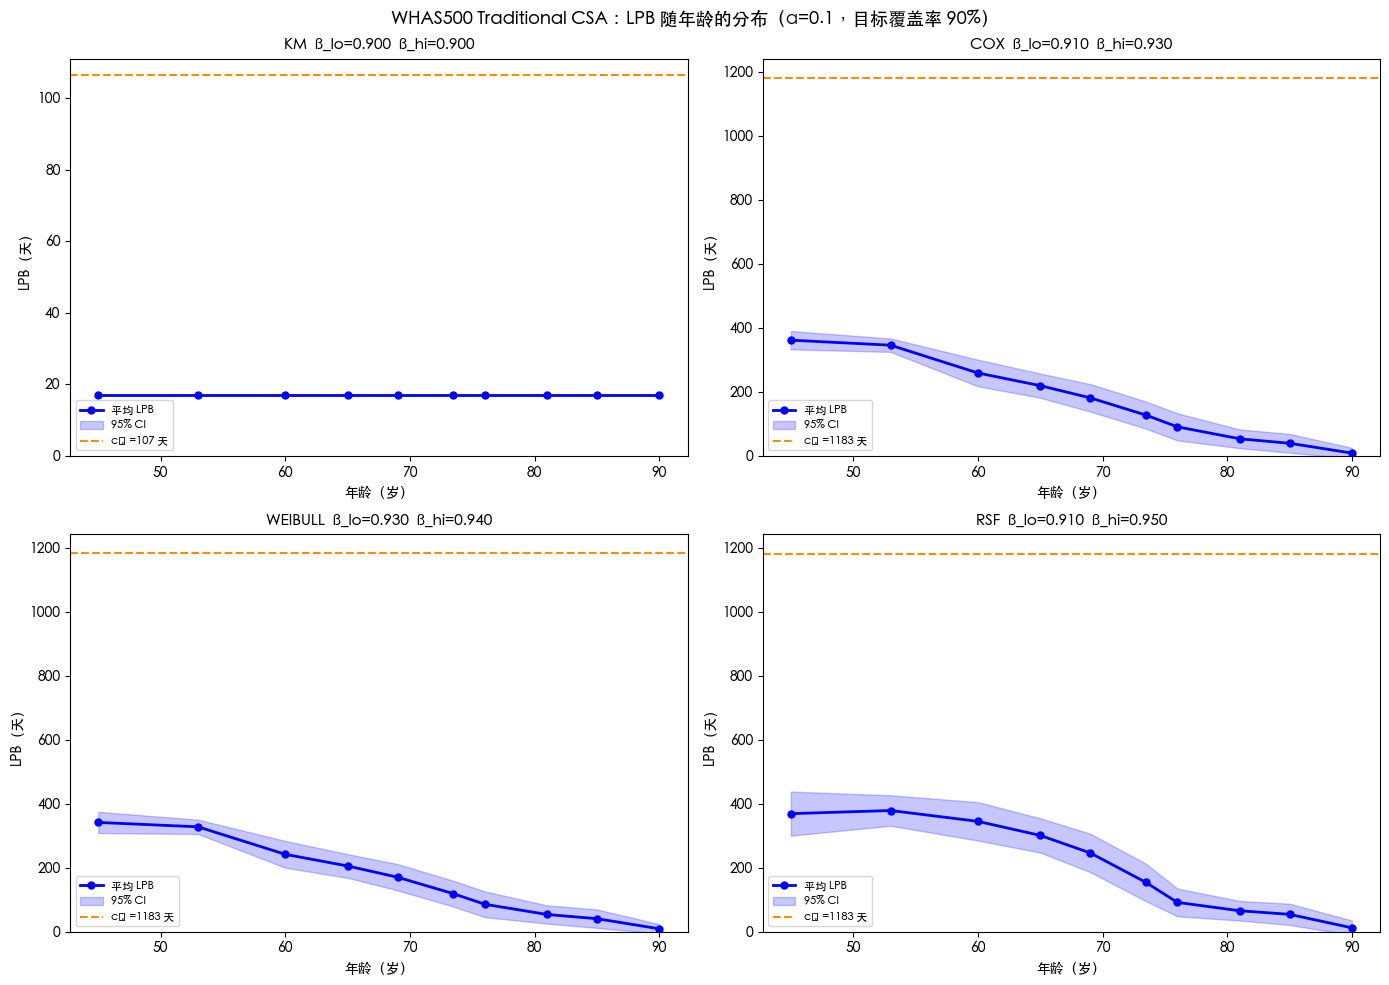

In [10]:

age_idx = feature_names_whas.index('age') if 'age' in feature_names_whas else 0
age_te  = X_te_w[:, age_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('WHAS500 Traditional CSA：LPB 随年龄的分布（α=0.1，目标覆盖率 90%）',
             fontsize=13, fontweight='bold')

for ax, res in zip(axes.flatten(), whas_csa_results):
    mt  = res['model_type']
    lb  = res['_lower']
    c0  = res['c0_chosen']

    # 按年龄十分位滑窗计算平均 LPB ± 1.96 SE
    pcts  = np.percentile(age_te, np.linspace(5, 95, 10))
    bw    = (pcts[-1] - pcts[0]) / len(pcts) * 1.2
    m_lb, s_lb = [], []
    for p in pcts:
        mask = np.abs(age_te - p) <= bw
        if mask.sum() > 1:
            m_lb.append(np.mean(lb[mask]))
            s_lb.append(np.std(lb[mask]) / np.sqrt(mask.sum()))
        else:
            m_lb.append(np.nan); s_lb.append(np.nan)
    m_lb, s_lb = np.array(m_lb), np.array(s_lb)

    ax.plot(pcts, m_lb, 'b-o', lw=2, ms=5, label='平均 LPB')
    ax.fill_between(pcts, m_lb - 1.96*s_lb, m_lb + 1.96*s_lb,
                    alpha=0.22, color='blue', label='95% CI')
    ax.axhline(c0, color='darkorange', ls='--', lw=1.5, label=f'c₀={c0:.0f} 天')
    ax.set_xlabel('年龄（岁）', fontsize=10)
    ax.set_ylabel('LPB（天）', fontsize=10)
    ax.set_title(f'{mt.upper()}  β_lo={res["beta_lo"]:.3f}  β_hi={res["beta_hi"]:.3f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('WHAS500_LPB_vs_age.png', dpi=120, bbox_inches='tight')
plt.show()


## 第三部分：真实数据（WHAS500）CSA 实验结果分析

**主要发现**

- 仅 KM 满足覆盖率下界保证（β_lo = 0.900 ≥ 0.90）；Cox（β_lo = 0.880）、Weibull（β_lo = 0.890）、RSF（β_lo = 0.890）均未达到理论保证，方法迁移至真实数据后严格性受损。
- KM 选择极小的 c₀ = 22 天（P(C ≥ c₀) = 0.90），LPB 退化为对所有个体的常数约 17 天，丧失临床区分价值；Cox/Weibull/RSF 选择 c₀ = 1957 天，校准集仅剩 53 个样本（43 未删失 + 10 删失且 C ≥ c₀），LPB 均值达 189–205 天，个体化程度更高。
- 未删失覆盖率均不达标：KM = 0.767，Cox/Weibull/RSF 均为 0.884，低于 0.90 目标；KM 删失覆盖率恒为 1.000（LPB = 17 天对所有删失样本必然成立），Cox/Weibull/RSF 删失覆盖率为 0.877–0.895。
- β_lo = β_hi 仅对 KM 成立（测试集中无"删失且 T̃ < L̂"样本）；Cox/Weibull/RSF 因 LPB 较大出现该情形，β_hi = 0.95 > β_lo，真实覆盖率区间为 [0.88–0.89, 0.95]。

**不足与改进方向**

- 真实数据中删失时间 C 不可观测，权重估计以观测时间 T̃ 为代理，引入近似误差，这是 Cox/Weibull/RSF 未能满足形式覆盖保证的主要原因之一。
- c₀ 的极端选择（KM 选最小、其余选最大）揭示了 c₀ 网格搜索设计的局限性：应引入校准集覆盖率验证约束，避免 LPB 退化或 c₀ 过激。
- 测试集仅 100 例（未删失 43），覆盖率估计方差较大，建议多次随机分割取均值以评估稳定性。
- 未与无权重版本及竞争方法对比，IPCW 校正的实际增益尚未量化。

## 第四部分：Alpha 阈值优化分析（WHAS500）

通过在不同 α 值下重复实验，观察实际覆盖率与平均 LPB 随 α 变化的曲线，寻找效率拐点以确定最优 α。

  alpha=0.01  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.01  cox      beta_lo=1.000  mean_LPB=0.6
  alpha=0.01  weibull  beta_lo=1.000  mean_LPB=0.9
  alpha=0.01  rsf      beta_lo=1.000  mean_LPB=0.3
  alpha=0.02  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.02  cox      beta_lo=0.960  mean_LPB=57.4
  alpha=0.02  weibull  beta_lo=0.960  mean_LPB=72.5
  alpha=0.02  rsf      beta_lo=1.000  mean_LPB=39.1
  alpha=0.03  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.03  cox      beta_lo=0.960  mean_LPB=87.3
  alpha=0.03  weibull  beta_lo=0.960  mean_LPB=81.1
  alpha=0.03  rsf      beta_lo=0.970  mean_LPB=54.7
  alpha=0.04  km       beta_lo=1.000  mean_LPB=1.0
  alpha=0.04  cox      beta_lo=0.950  mean_LPB=96.5
  alpha=0.04  weibull  beta_lo=0.960  mean_LPB=91.1
  alpha=0.04  rsf      beta_lo=0.970  mean_LPB=57.4
  alpha=0.05  km       beta_lo=0.990  mean_LPB=2.0
  alpha=0.05  cox      beta_lo=0.950  mean_LPB=112.0
  alpha=0.05  weibull  beta_lo=0.950  mean_LPB=103.7
  alpha=0.05  rsf 

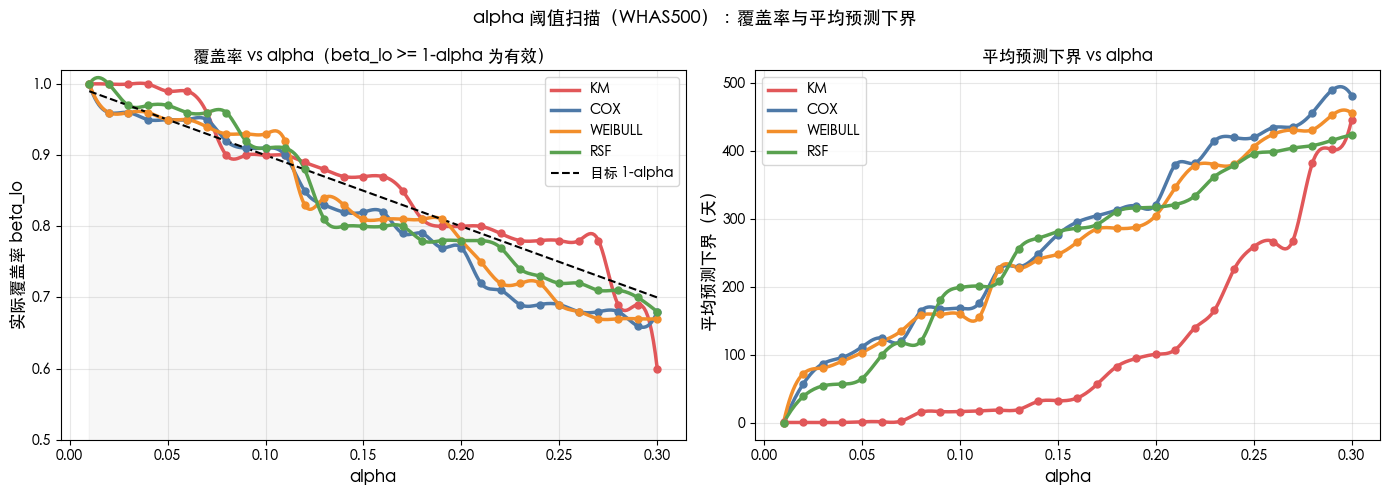


最优 alpha 选择（满足 beta_lo >= 1-alpha 的最大 alpha）：
  KM      : alpha*=0.27  beta_lo=0.780  mean_LPB=268.0
  COX     : alpha*=0.11  beta_lo=0.900  mean_LPB=176.7
  WEIBULL : alpha*=0.19  beta_lo=0.810  mean_LPB=287.9
  RSF     : alpha*=0.12  beta_lo=0.880  mean_LPB=208.3


In [16]:

alpha_list = [round(x * 0.01, 2) for x in range(1, 31)]
model_types = ['km', 'cox', 'weibull', 'rsf']
model_map_w = {'km': kmf_w, 'cox': cox_w, 'weibull': weibull_w, 'rsf': rsf_w}

sweep_records = []

for alpha in alpha_list:
    for model_type in model_types:
        model = model_map_w[model_type]
        lower_s, upper_s, _, _ = fit_csa_intervals_traditional(
            model,
            X_tr_w, time_tr_w, event_tr_w,
            X_cal_w, time_cal_w, event_cal_w,
            X_te_w,
            alpha=alpha,
            model_type=model_type,
            use_weights=True,
            verbose=False
        )
        m_s = evaluate_interval_coverage_traditional(lower_s, upper_s, time_te_w, event_te_w)
        sweep_records.append({
            'alpha':    alpha,
            'model':    model_type,
            'beta_lo':  m_s['beta_lo'],
            'mean_lpb': float(lower_s.mean()),
        })
        print(f"  alpha={alpha:.2f}  {model_type:7s}  beta_lo={m_s['beta_lo']:.3f}  mean_LPB={lower_s.mean():.1f}")

df_sweep = pd.DataFrame(sweep_records)

# --- 平滑曲线可视化 ---
from scipy.interpolate import make_interp_spline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'km': '#e15759', 'cox': '#4e79a7', 'weibull': '#f28e2b', 'rsf': '#59a14f'}
alphas_fine = np.linspace(min(alpha_list), max(alpha_list), 300)

for mt in model_types:
    sub = df_sweep[df_sweep['model'] == mt].sort_values('alpha')
    a_pts = sub['alpha'].values
    c_pts = sub['beta_lo'].values
    l_pts = sub['mean_lpb'].values

    spl_cov = make_interp_spline(a_pts, c_pts, k=3)
    spl_lpb = make_interp_spline(a_pts, l_pts, k=3)

    ax1.plot(alphas_fine, spl_cov(alphas_fine), color=colors[mt], lw=2.5, label=mt.upper())
    ax1.scatter(a_pts, c_pts, color=colors[mt], s=25, zorder=5)

    ax2.plot(alphas_fine, spl_lpb(alphas_fine), color=colors[mt], lw=2.5, label=mt.upper())
    ax2.scatter(a_pts, l_pts, color=colors[mt], s=25, zorder=5)

alphas_arr = np.array(alpha_list)
ax1.plot(alphas_arr, 1 - alphas_arr, 'k--', lw=1.5, label='目标 1-alpha')
ax1.fill_between(alphas_arr, 0, 1 - alphas_arr, alpha=0.06, color='gray')
ax1.set_xlabel('alpha', fontsize=12)
ax1.set_ylabel('实际覆盖率 beta_lo', fontsize=12)
ax1.set_title('覆盖率 vs alpha（beta_lo >= 1-alpha 为有效）', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim(0.5, 1.02)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('alpha', fontsize=12)
ax2.set_ylabel('平均预测下界（天）', fontsize=12)
ax2.set_title('平均预测下界 vs alpha', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('alpha 阈值扫描（WHAS500）：覆盖率与平均预测下界', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('alpha_sweep_WHAS500.png', dpi=120, bbox_inches='tight')
plt.show()

# --- 最优 alpha：满足覆盖保证的最大 alpha ---
print('\n最优 alpha 选择（满足 beta_lo >= 1-alpha 的最大 alpha）：')
for mt in model_types:
    sub = df_sweep[df_sweep['model'] == mt]
    valid = sub[sub['beta_lo'] >= 1 - sub['alpha']]
    if not valid.empty:
        opt = valid.iloc[-1]
        print(f"  {mt.upper():8s}: alpha*={opt['alpha']:.2f}  beta_lo={opt['beta_lo']:.3f}  mean_LPB={opt['mean_lpb']:.1f}")
    else:
        print(f"  {mt.upper():8s}: 无满足条件的 alpha")


## 第五部分：合成数据 Alpha-覆盖率分析

在三种样本量场景下（n=100/500/2000）扫描 α，验证保形预测覆盖保证在不同 α 下的表现。

n=100  km       done
n=100  cox      done
n=100  weibull  done
n=100  rsf      done
n=500  km       done
n=500  cox      done
n=500  weibull  done
n=500  rsf      done
n=2000  km       done
n=2000  cox      done
n=2000  weibull  done
n=2000  rsf      done


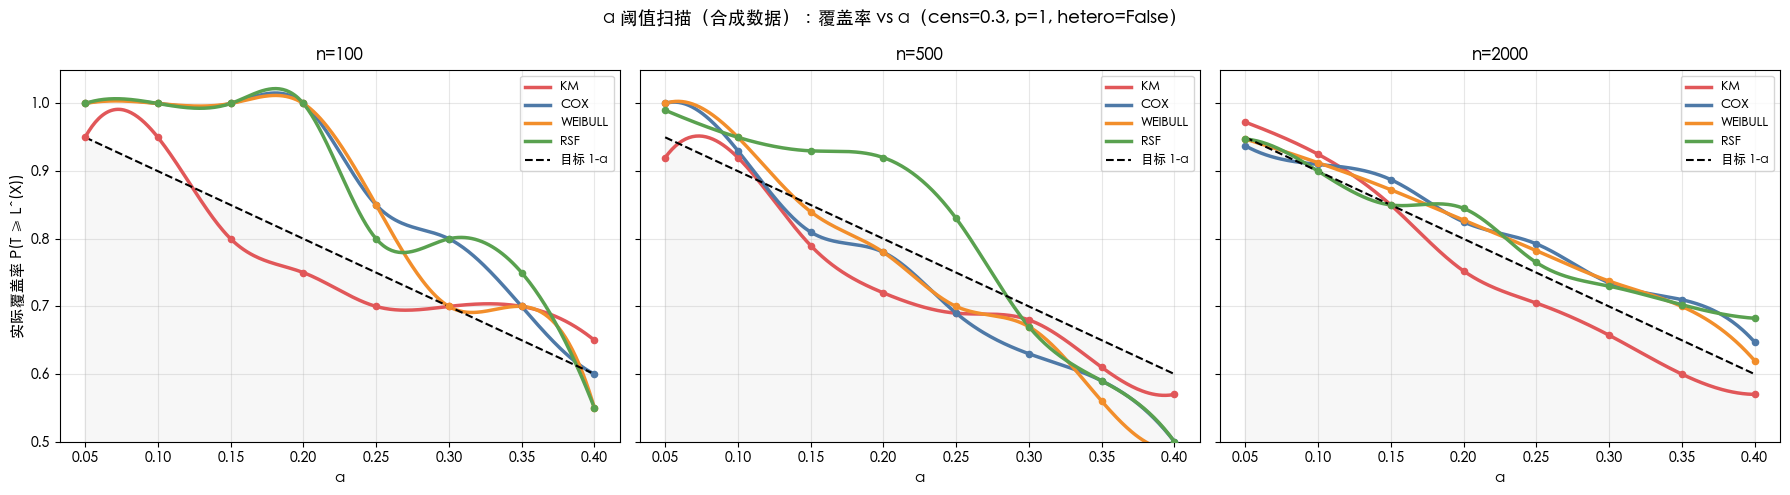

In [17]:
from scipy.interpolate import make_interp_spline

# 三个代表性场景：n=100/500/2000，cens=0.3，p=1，hetero=False
# 索引：n_idx*12 + cens_idx*4 + p_idx*2 + hetero_idx = [4, 16, 28]
scenario_indices = {100: 4, 500: 16, 2000: 28}
alpha_list_syn = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
base_models = ['km', 'cox', 'weibull', 'rsf']
colors = {'km': '#e15759', 'cox': '#4e79a7', 'weibull': '#f28e2b', 'rsf': '#59a14f'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('α 阈值扫描（合成数据）：覆盖率 vs α（cens=0.3, p=1, hetero=False）',
             fontsize=13, fontweight='bold')

for ax, (n_val, idx) in zip(axes, scenario_indices.items()):
    X_s, surv_s, time_s, event_s = datasets[idx]
    time_true_s = time_trues[idx]
    cens_time_s = cens_times[idx]

    (X_tr_s, time_tr_s, event_tr_s,
     X_cal_s, time_cal_s, event_cal_s,
     X_te_s, time_te_s, event_te_s,
     _, _, ttrue_te_s,
     cens_tr_s, cens_cal_s, _) = split_survival_data(
        X_s, time_s, event_s,
        time_true=time_true_s, cens_time=cens_time_s,
        test_size=0.2, cal_size=0.25, random_state=2026
    )

    kmf_s     = fit_kaplan_meier(time_tr_s, event_tr_s)
    cox_s     = fit_cox(X_tr_s, time_tr_s, event_tr_s)
    weibull_s = fit_weibull(X_tr_s, time_tr_s, event_tr_s)
    rsf_s     = fit_rsf(X_tr_s, time_tr_s, event_tr_s)
    model_map_s = {'km': kmf_s, 'cox': cox_s, 'weibull': weibull_s, 'rsf': rsf_s}

    for mt in base_models:
        coverages = []
        for alpha in alpha_list_syn:
            lower_s2, _, _, _ = fit_csa_intervals_traditional(
                model_map_s[mt],
                X_tr_s, time_tr_s, event_tr_s,
                X_cal_s, time_cal_s, event_cal_s,
                X_te_s, alpha=alpha, model_type=mt,
                use_weights=True,
                cens_time_train=cens_tr_s, cens_time_cal=cens_cal_s,
                verbose=False
            )
            m2 = evaluate_interval_coverage_traditional_synthetic(lower_s2, ttrue_te_s, event_te_s)
            coverages.append(m2['coverage'])
        # 所有 alpha 收集完毕后再绘图
        a_arr = np.array(alpha_list_syn)
        c_arr = np.array(coverages)
        a_fine = np.linspace(a_arr.min(), a_arr.max(), 300)
        spl = make_interp_spline(a_arr, c_arr, k=3)
        ax.plot(a_fine, spl(a_fine), color=colors[mt], lw=2.5, label=mt.upper())
        ax.scatter(a_arr, c_arr, color=colors[mt], s=20, zorder=5)
        print(f"n={n_val}  {mt:7s}  done")

    alphas_arr = np.array(alpha_list_syn)
    ax.plot(alphas_arr, 1 - alphas_arr, 'k--', lw=1.5, label='目标 1-α')
    ax.fill_between(alphas_arr, 0, 1 - alphas_arr, alpha=0.06, color='gray')
    ax.set_xlabel('α', fontsize=11)
    ax.set_title(f'n={n_val}', fontsize=12)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('实际覆盖率 P(T ≥ L̂(X))', fontsize=11)
plt.tight_layout()
plt.savefig('alpha_sweep_synthetic.png', dpi=120, bbox_inches='tight')
plt.show()
